In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
%env OMP_NUM_THREADS=1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

env: OMP_NUM_THREADS=1


In [2]:


# Load dataset
df = pd.read_csv("../datasets/iris_dataset.csv")

# Display first five rows
print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (150, 5)


In [5]:
print(df.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [6]:
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Duplicate Rows: 3


In [7]:
X = df.drop("species", axis=1)

In [8]:
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [9]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

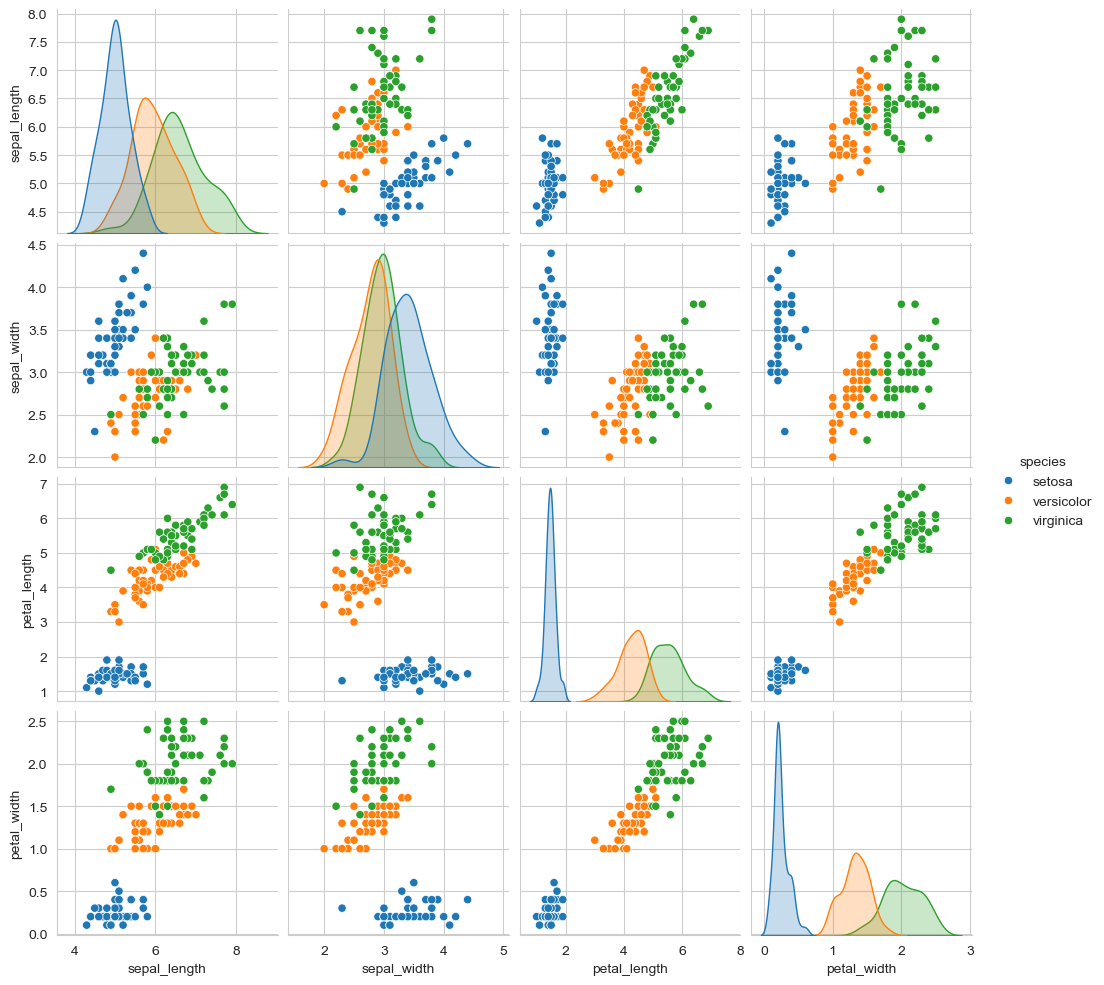

In [11]:
sns.pairplot(df, hue="species")
plt.show()

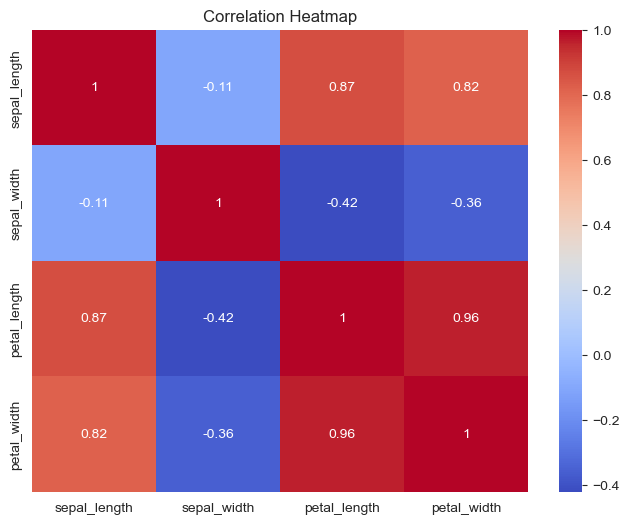

In [12]:
numeric_df = df.drop(columns=["species"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

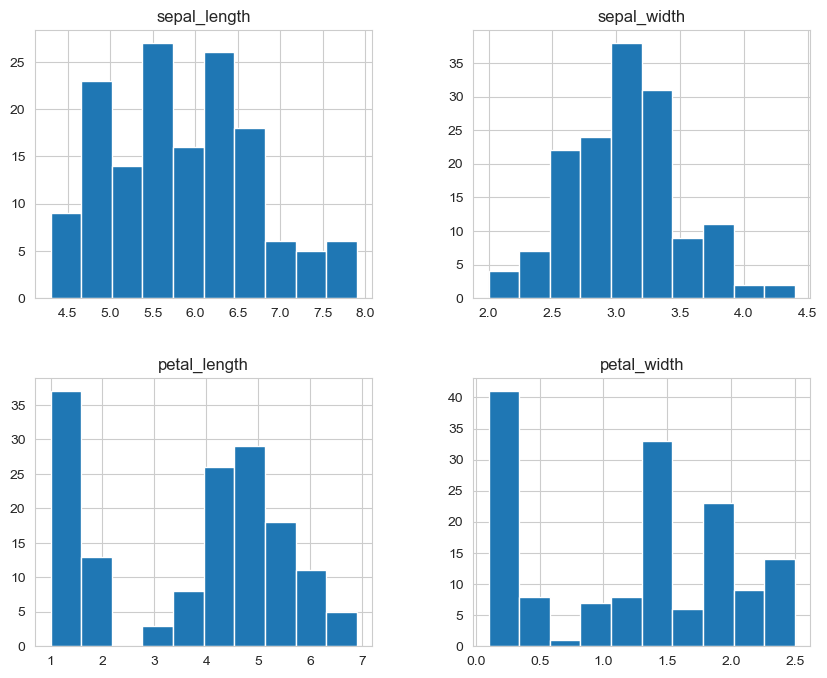

In [13]:
df.hist(figsize=(10,8))
plt.show()

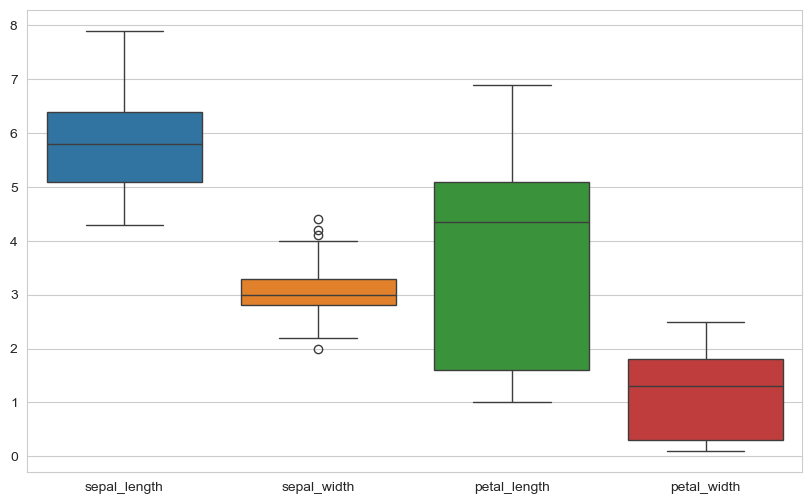

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.drop(columns=["species"]))
plt.show()

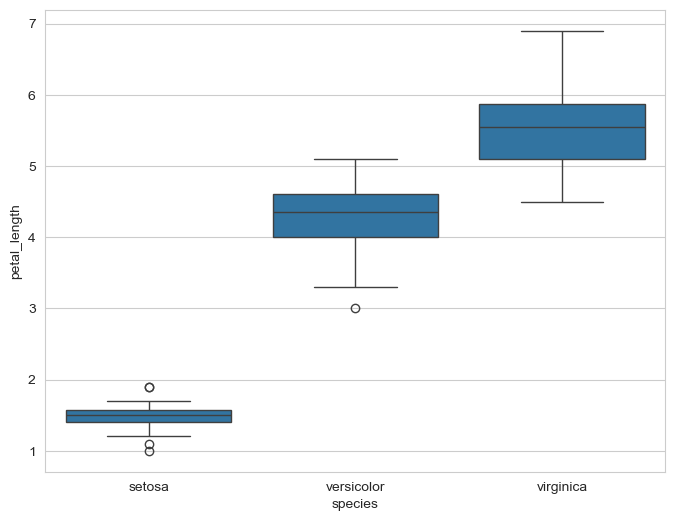

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x="species", y="petal_length", data=df)
plt.show()

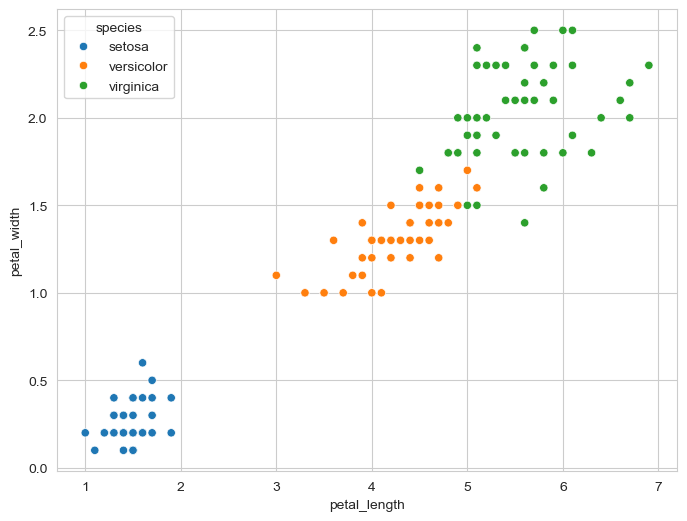

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)
plt.show()

In [17]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
inertia = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

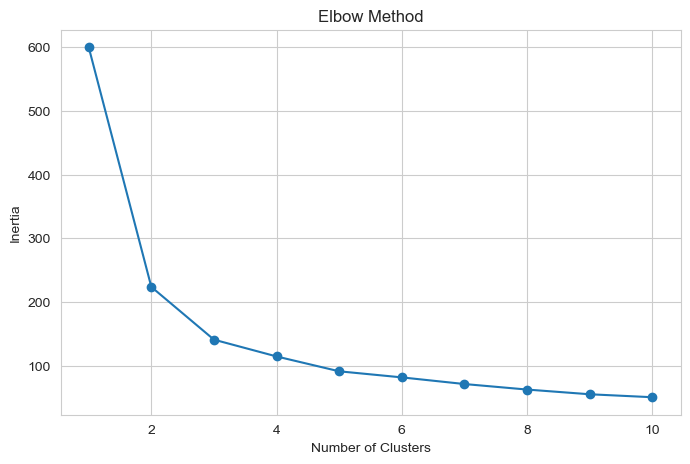

In [20]:

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.savefig("../images/Elbow_Method.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [21]:

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

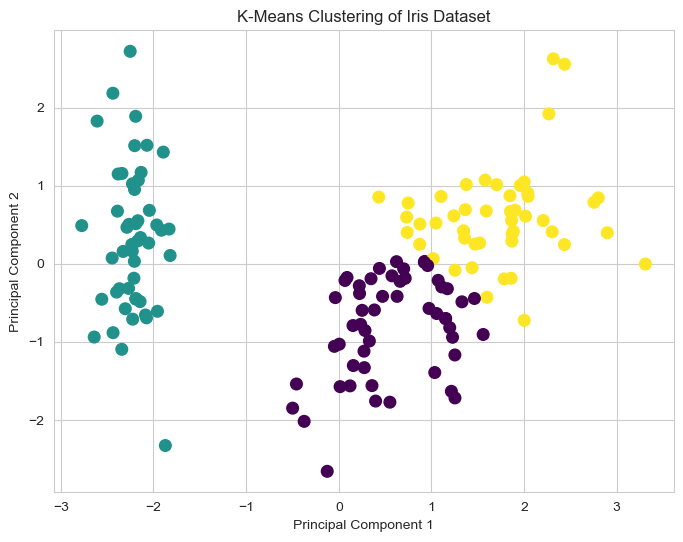

In [22]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis",
    s=70
)

plt.title("K-Means Clustering of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("../images/KMeans_Clusters.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [24]:
df.to_csv("iris_clustered.csv", index=False)


In [26]:
df.groupby("species").mean()


,sepal_length,sepal_width,petal_length,petal_width,Cluster
species,,,,,
setosa,5.006,3.418,1.464,0.244,1.00
versicolor,5.936,2.770,4.260,1.326,0.44
virginica,6.588,2.974,5.552,2.026,1.44
